In [87]:
import warnings
warnings.filterwarnings('ignore')

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset

In [89]:
df = pd.read_excel(r"C:\Users\Admin\Documents\project dataset.xlsx")

# Check the first 10 rows of the dataset

In [90]:
df.head(10)

,date,time,kiosk_id,kiosk_location,customer_id,tank_capacity_liters,water_level_before_refill,liters_sold,price_per_liter,total_sales_kes,payment_method,temperature_c,rainfall_mm,refill_status,truck_arrival_delay_min,daily_population_served,sensor_status,water_quality_score,holiday_flag,weekend_flag
0,2024-06-24,13:16:00,KSK013,Area A,CUST5365,2000.0,2839.35,1299.61,3.77,4899.53,Mobile Money,27.7,47.8,Not Refilled,43.5,550,Active,62.7,No,No
1,2024-07-15,10:59:00,KSK037,Area A,CUST6097,10000.0,1518.12,6538.53,3.93,25696.42,Cash,30.6,32.9,Refilled,34.1,402,Active,63.9,No,No
2,2025-06-21,23:30:00,KSK012,Area B,CUST1487,10000.0,2069.45,5696.66,4.03,22957.54,Mobile Money,35.6,56.1,Not Refilled,42.1,91,Active,69.3,No,Yes
3,2025-05-17,08:12:00,KSK013,Area B,CUST5879,3000.0,2815.74,1571.97,1.55,2436.55,Cash,30.0,79.6,Refilled,35.7,537,Active,99.9,No,Yes
4,2025-08-02,07:15:00,KSK047,Area B,CUST1965,2000.0,1548.05,1581.45,3.14,4965.75,Mobile Money,33.4,51.6,Refilled,31.2,385,Active,98.6,No,Yes
5,2024-07-30,12:46:00,KSK034,Area A,CUST8883,3000.0,516.01,1607.46,4.02,6461.99,Cash,27.8,51.1,Refilled,34.4,302,Active,86.0,No,No
6,2025-09-07,16:17:00,KSK007,Area B,CUST1448,5000.0,1821.27,2578.02,2.04,5259.16,Mobile Money,27.0,51.8,Refilled,68.1,522,Active,67.3,No,Yes
7,2024-12-14,02:14:00,KSK003,Area A,CUST9684,7000.0,1366.33,4870.49,2.88,14027.01,Card,34.3,39.1,Not Refilled,53.3,122,Active,69.5,Yes,Yes
8,2024-07-04,03:17:00,KSK035,Area B,CUST2493,3000.0,2846.89,1490.45,3.52,5246.38,Mobile Money,32.4,50.1,Refilled,38.7,81,Active,92.7,No,No
9,2025-02-02,16:24:00,KSK015,Area B,CUST6203,5000.0,1618.20,3637.93,2.81,10222.58,Cash,27.9,64.4,Refilled,7.9,544,Active,98.7,No,Yes


# Determine the dimensions

In [91]:
df.shape

(5000, 20)

### Display the variable names

In [92]:
df.columns

Index(['date', 'time', 'kiosk_id', 'kiosk_location', 'customer_id',
       'tank_capacity_liters', 'water_level_before_refill', 'liters_sold',
       'price_per_liter', 'total_sales_kes', 'payment_method', 'temperature_c',
       'rainfall_mm', 'refill_status', 'truck_arrival_delay_min',
       'daily_population_served', 'sensor_status', 'water_quality_score',
       'holiday_flag', 'weekend_flag'],
      dtype='str')

# Check data types

In [93]:
df.dtypes

date                         datetime64[us]
time                                 object
kiosk_id                                str
kiosk_location                          str
customer_id                             str
tank_capacity_liters                float64
water_level_before_refill           float64
liters_sold                         float64
price_per_liter                     float64
total_sales_kes                     float64
payment_method                          str
temperature_c                       float64
rainfall_mm                         float64
refill_status                           str
truck_arrival_delay_min             float64
daily_population_served               int64
sensor_status                           str
water_quality_score                 float64
holiday_flag                            str
weekend_flag                            str
dtype: object

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       5000 non-null   datetime64[us]
 1   time                       5000 non-null   object        
 2   kiosk_id                   5000 non-null   str           
 3   kiosk_location             5000 non-null   str           
 4   customer_id                5000 non-null   str           
 5   tank_capacity_liters       4880 non-null   float64       
 6   water_level_before_refill  5000 non-null   float64       
 7   liters_sold                4880 non-null   float64       
 8   price_per_liter            5000 non-null   float64       
 9   total_sales_kes            5000 non-null   float64       
 10  payment_method             4880 non-null   str           
 11  temperature_c              4881 non-null   float64       
 12  rainfall_mm      

### Check for missing values

In [95]:
df.isnull().sum()

date                           0
time                           0
kiosk_id                       0
kiosk_location                 0
customer_id                    0
tank_capacity_liters         120
water_level_before_refill      0
liters_sold                  120
price_per_liter                0
total_sales_kes                0
payment_method               120
temperature_c                119
rainfall_mm                  120
refill_status                  0
truck_arrival_delay_min      120
daily_population_served        0
sensor_status                  0
water_quality_score          120
holiday_flag                   0
weekend_flag                   0
dtype: int64

### Percentage of the missing values

In [96]:
missing = (df.isnull().sum() / len(df)) * 100
missing.sort_values(ascending=False)

rainfall_mm                  2.40
payment_method               2.40
liters_sold                  2.40
tank_capacity_liters         2.40
truck_arrival_delay_min      2.40
water_quality_score          2.40
temperature_c                2.38
date                         0.00
kiosk_location               0.00
kiosk_id                     0.00
time                         0.00
water_level_before_refill    0.00
price_per_liter              0.00
total_sales_kes              0.00
customer_id                  0.00
refill_status                0.00
daily_population_served      0.00
sensor_status                0.00
holiday_flag                 0.00
weekend_flag                 0.00
dtype: float64

### Handle missing values

In [97]:
df['tank_capacity_liters'] = df['tank_capacity_liters'].fillna(df['tank_capacity_liters'].median())

In [98]:
df['liters_sold'] = df['liters_sold'].fillna(df['liters_sold'].median())

In [99]:
df['temperature_c'] = df['temperature_c'].fillna(df['temperature_c'].median())

In [100]:
df['rainfall_mm'] = df['rainfall_mm'].fillna(df['rainfall_mm'].median())

In [101]:
df['truck_arrival_delay_min'] = df['truck_arrival_delay_min'].fillna(df['truck_arrival_delay_min'].median())

In [102]:
df['water_quality_score'] = df['water_quality_score'].fillna(df['water_quality_score'].median())

In [103]:
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])

# Check for duplicate observations

In [104]:
df.duplicated().sum()

np.int64(0)

### Check for inconsistent values

In [105]:
# For categorical variables
categorical = df.select_dtypes(include="object").columns

for col in categorical:
    print(f"\n{col}")
    print(df[col].value_counts())


time
time
10:12:00    11
21:12:00    10
17:09:00    10
16:49:00    10
22:08:00    10
            ..
20:52:00     1
12:19:00     1
02:45:00     1
16:25:00     1
16:57:00     1
Name: count, Length: 1394, dtype: int64

kiosk_id
kiosk_id
KSK042    132
KSK006    131
KSK020    122
KSK023    120
KSK033    120
KSK028    118
KSK015    113
KSK004    113
KSK026    113
KSK008    110
KSK046    110
KSK012    108
KSK043    106
KSK045    106
KSK025    105
KSK036    104
KSK027    103
KSK009    103
KSK041    103
KSK049    102
KSK017    101
KSK001    100
KSK003     99
KSK037     98
KSK034     98
KSK013     97
KSK029     97
KSK048     97
KSK031     97
KSK022     96
KSK044     96
KSK047     94
KSK007     94
KSK039     94
KSK024     94
KSK002     94
KSK040     93
KSK032     93
KSK011     93
KSK050     91
KSK014     90
KSK038     89
KSK016     89
KSK018     87
KSK010     83
KSK005     82
KSK021     82
KSK035     81
KSK030     81
KSK019     78
Name: count, dtype: int64

kiosk_location
kiosk_location
Area A  

# Standardize texts

In [106]:
for col in categorical:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip().str.lower()

### Detect Outliers

In [107]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [108]:
for col in numeric_cols:

 Q1 = df[col].quantile(0.25)
 Q3 = df[col].quantile(0.75)

 IQR = Q3 - Q1

 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR

 outliers = df[
    (df[col] < lower) |
    (df[col] > upper)
]

 print(f"{col}: {outliers.shape[0]}")

tank_capacity_liters: 0
water_level_before_refill: 0
liters_sold: 17
price_per_liter: 0
total_sales_kes: 89
temperature_c: 65
rainfall_mm: 48
truck_arrival_delay_min: 43
daily_population_served: 0
water_quality_score: 0


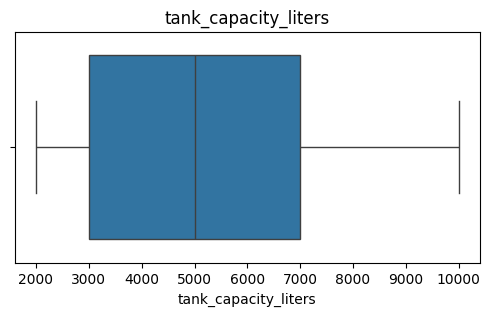

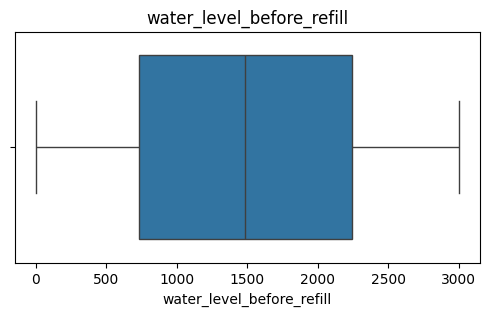

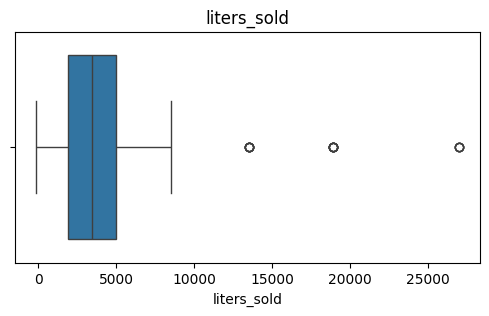

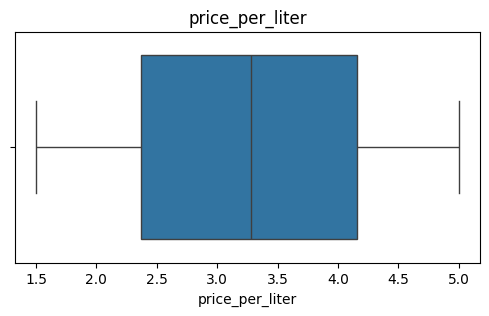

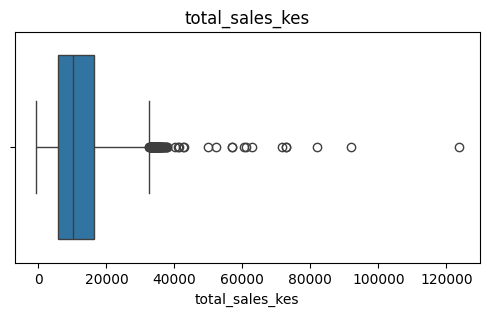

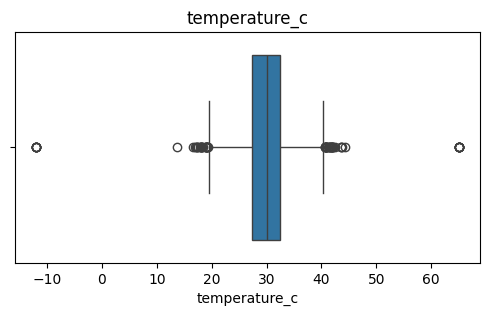

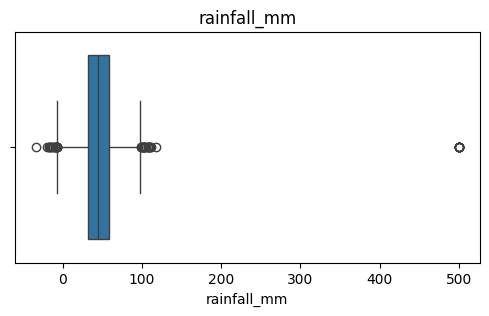

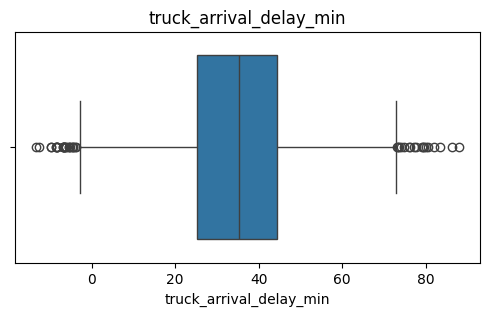

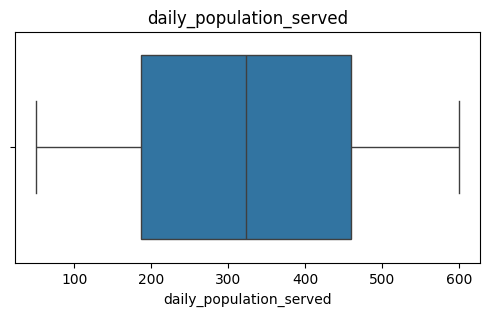

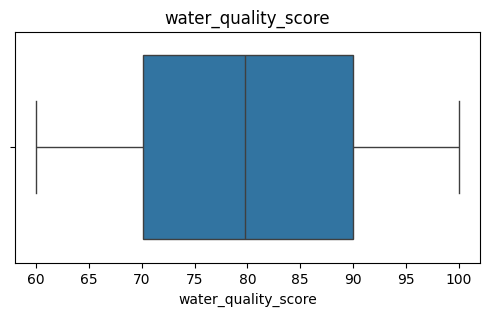

In [109]:
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.savefig(f"boxplot_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

### Capping outliers using winsorization

In [110]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

In [111]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {outliers.shape[0]}")

tank_capacity_liters: 0
water_level_before_refill: 0
liters_sold: 0
price_per_liter: 0
total_sales_kes: 0
temperature_c: 0
rainfall_mm: 0
truck_arrival_delay_min: 0
daily_population_served: 0
water_quality_score: 0


# Convert data types

In [112]:
df['date'] = pd.to_datetime(df['date'])

df['time'] = pd.to_datetime(
    df['time'],
    format='%H:%M:%S'
).dt.time

# Encode categorical variables

In [113]:
df.select_dtypes(include="object").columns

Index(['time', 'kiosk_id', 'kiosk_location', 'customer_id', 'payment_method',
       'refill_status', 'sensor_status', 'holiday_flag', 'weekend_flag'],
      dtype='str')

In [114]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "kiosk_location",
        "payment_method",
        "refill_status",
        "sensor_status"
    ],
    drop_first=True
)

### Scale numerical features

In [115]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = [
    "tank_capacity_liters",
    "water_level_before_refill",
    "liters_sold",
    "price_per_liter",
    "total_sales_kes",
    "temperature_c",
    "rainfall_mm",
    "truck_arrival_delay_min",
    "daily_population_served",
    "water_quality_score"
]

df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

### Feature Engineering

In [116]:
# Day of the week
df["day_of_week"] = df["date"].dt.day_name()

In [117]:
# Month
df["month"] = df["date"].dt.month_name()

In [118]:
# Hour of the day
df["hour"] = pd.to_datetime(df["time"], format="%H:%M:%S").dt.hour

In [119]:
# Water usage percentage
df["water_usage_percent"] = (
    df["liters_sold"] / df["tank_capacity_liters"]
) * 100

In [120]:
df = df.drop(columns=["water_usage_percent"])

### Create a copy of my cleaned dataset

In [121]:
df_encoded = df.copy()

### Encode only the categorical variables needed for modelling

In [122]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=[
        "kiosk_location",
        "payment_method",
        "refill_status",
        "sensor_status",
        "holiday_flag",
        "weekend_flag"
    ],
    drop_first=True
)

### Handle identifiers

In [123]:
df_encoded = df_encoded.drop(columns=["kiosk_id", "customer_id"])

# Handle the date and time columns

In [124]:
df_encoded = df_encoded.drop(columns=["date", "time"])

# Encode day_of_week and Month

In [125]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["day_of_week", "month"],
    drop_first=True
)

### Check the result

In [126]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tank_capacity_liters         5000 non-null   float64
 1   water_level_before_refill    5000 non-null   float64
 2   liters_sold                  5000 non-null   float64
 3   price_per_liter              5000 non-null   float64
 4   total_sales_kes              5000 non-null   float64
 5   temperature_c                5000 non-null   float64
 6   rainfall_mm                  5000 non-null   float64
 7   truck_arrival_delay_min      5000 non-null   float64
 8   daily_population_served      5000 non-null   int64  
 9   water_quality_score          5000 non-null   float64
 10  hour                         5000 non-null   int32  
 11  kiosk_location_Area B        5000 non-null   bool   
 12  payment_method_Cash          5000 non-null   bool   
 13  payment_method_Mobile Money  

### Generate summary statitics

In [127]:
df.describe()

,date,tank_capacity_liters,water_level_before_refill,liters_sold,price_per_liter,total_sales_kes,temperature_c,rainfall_mm,truck_arrival_delay_min,daily_population_served,water_quality_score,hour
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-12-25 11:28:01.920000,5389.800000,1490.706206,3659.850072,3.260610,11903.970959,29.94036,45.275200,34.928730,322.865400,79.960160,11.654400
min,2024-01-01 00:00:00,2000.000000,0.020000,-150.000000,1.500000,-721.500000,19.50000,-7.462500,-3.350000,50.000000,60.000000,0.000000
25%,2024-06-26 00:00:00,3000.000000,733.920000,1932.735000,2.370000,5837.362500,27.30000,32.175000,25.300000,187.000000,70.100000,6.000000
50%,2024-12-20 12:00:00,5000.000000,1479.730000,3416.435000,3.280000,10054.470000,30.00000,44.650000,35.200000,323.000000,79.800000,12.000000
75%,2025-06-23 06:00:00,7000.000000,2245.027500,4990.412500,4.160000,16475.422500,32.50000,58.600000,44.400000,459.000000,90.000000,18.000000
max,2025-12-30 00:00:00,10000.000000,2999.950000,9576.928750,5.000000,32432.512500,40.30000,98.237500,73.050000,599.000000,100.000000,23.000000
std,NaN,2822.737949,864.715504,2024.218907,1.017399,7802.726114,3.93949,19.789517,14.225816,157.648695,11.505692,6.855914


# Calculate the median

In [128]:
df.median(numeric_only=True)

tank_capacity_liters          5000.000
water_level_before_refill     1479.730
liters_sold                   3416.435
price_per_liter                  3.280
total_sales_kes              10054.470
temperature_c                   30.000
rainfall_mm                     44.650
truck_arrival_delay_min         35.200
daily_population_served        323.000
water_quality_score             79.800
hour                            12.000
dtype: float64

### Calculate the variance

In [129]:
df.var(numeric_only=True)

tank_capacity_liters         7.967850e+06
water_level_before_refill    7.477329e+05
liters_sold                  4.097462e+06
price_per_liter              1.035101e+00
total_sales_kes              6.088253e+07
temperature_c                1.551958e+01
rainfall_mm                  3.916250e+02
truck_arrival_delay_min      2.023738e+02
daily_population_served      2.485311e+04
water_quality_score          1.323810e+02
hour                         4.700356e+01
dtype: float64

### Calculate the standard deviation

In [130]:
df.std(numeric_only=True)

tank_capacity_liters         2822.737949
water_level_before_refill     864.715504
liters_sold                  2024.218907
price_per_liter                 1.017399
total_sales_kes              7802.726114
temperature_c                   3.939490
rainfall_mm                    19.789517
truck_arrival_delay_min        14.225816
daily_population_served       157.648695
water_quality_score            11.505692
hour                            6.855914
dtype: float64

### Display the frequency tables for all categorical variables

In [131]:
for col in categorical:
    print("=" * 50)
    print(f"Frequency Table for {col}")
    print(df[col].value_counts())

Frequency Table for time
time
10:12:00    11
21:12:00    10
17:09:00    10
16:49:00    10
22:08:00    10
            ..
20:52:00     1
12:19:00     1
02:45:00     1
16:25:00     1
16:57:00     1
Name: count, Length: 1394, dtype: int64
Frequency Table for kiosk_id
kiosk_id
KSK042    132
KSK006    131
KSK020    122
KSK023    120
KSK033    120
KSK028    118
KSK015    113
KSK004    113
KSK026    113
KSK008    110
KSK046    110
KSK012    108
KSK043    106
KSK045    106
KSK025    105
KSK036    104
KSK027    103
KSK009    103
KSK041    103
KSK049    102
KSK017    101
KSK001    100
KSK003     99
KSK037     98
KSK034     98
KSK013     97
KSK029     97
KSK048     97
KSK031     97
KSK022     96
KSK044     96
KSK047     94
KSK007     94
KSK039     94
KSK024     94
KSK002     94
KSK040     93
KSK032     93
KSK011     93
KSK050     91
KSK014     90
KSK038     89
KSK016     89
KSK018     87
KSK010     83
KSK005     82
KSK021     82
KSK035     81
KSK030     81
KSK019     78
Name: count, dtype: int64
F

# Generate histograms(distributions of numerical variables)

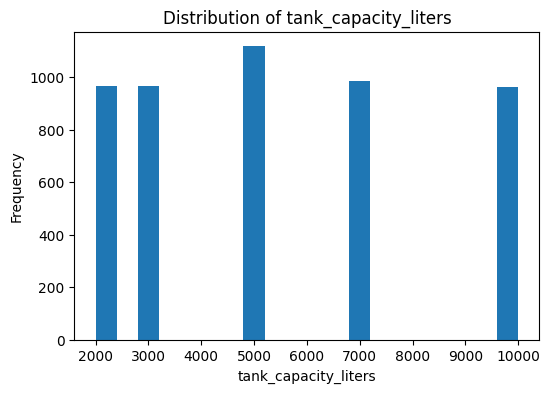

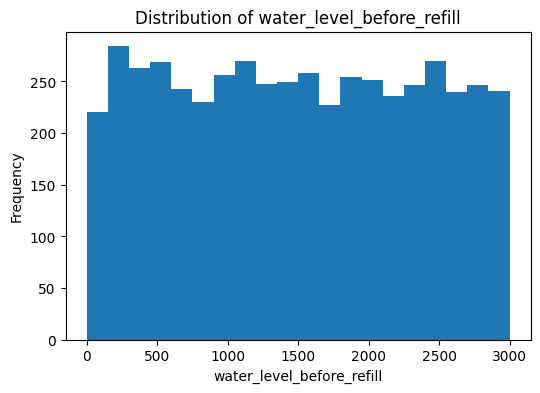

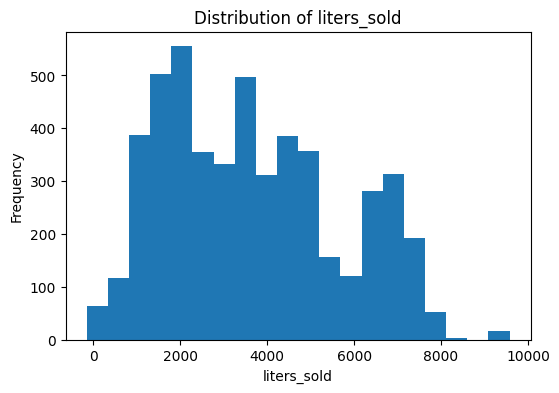

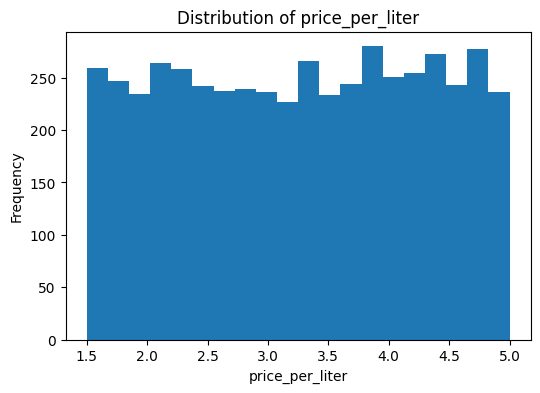

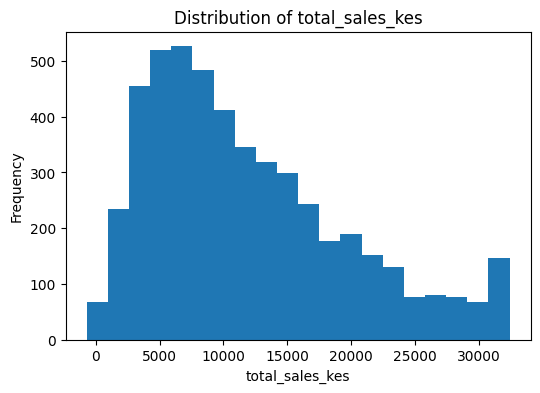

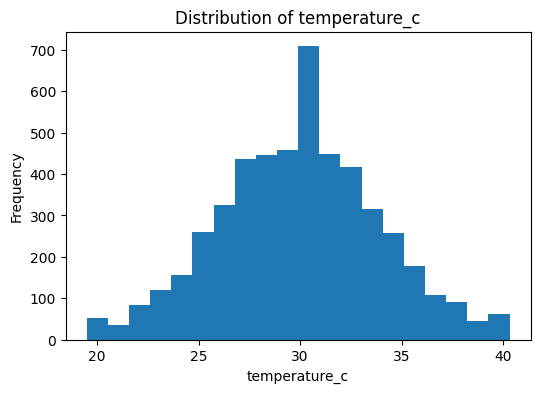

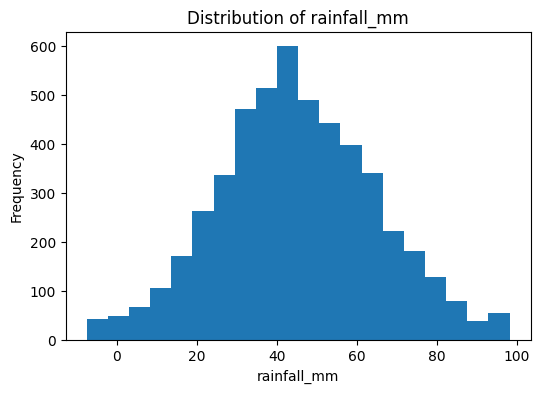

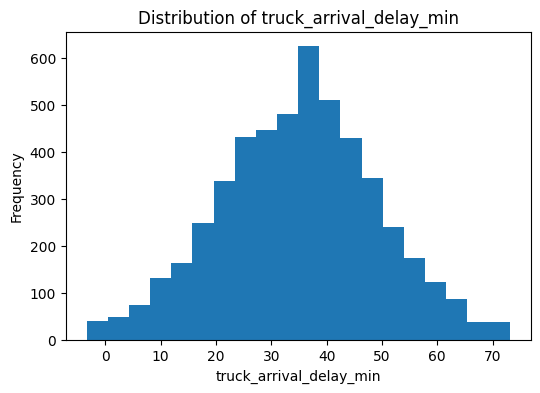

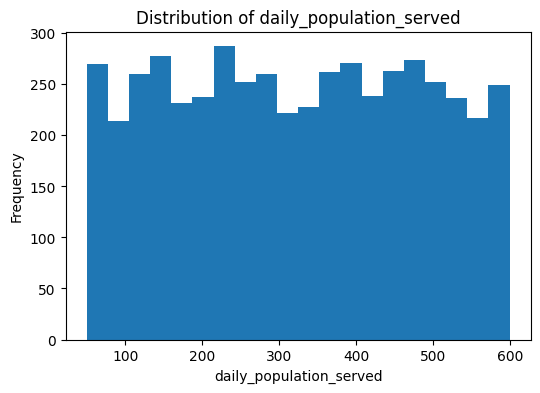

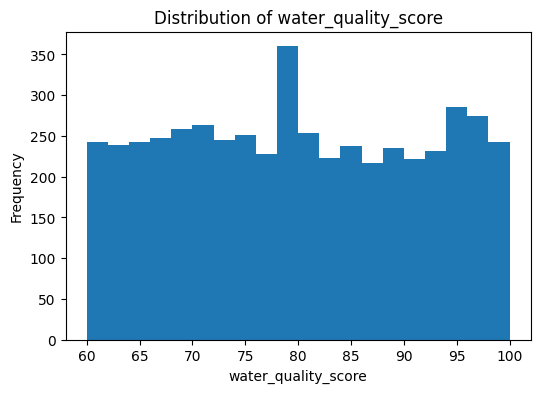

In [132]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.savefig(f"histogram_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

# Generate Boxplots

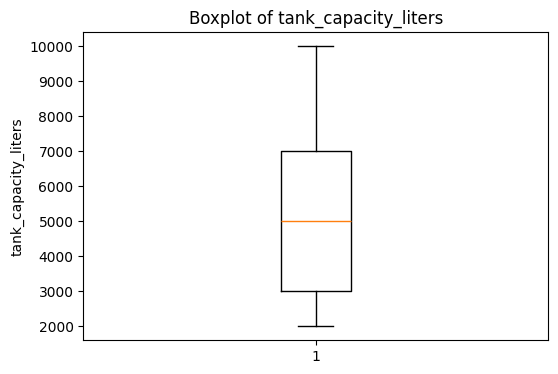

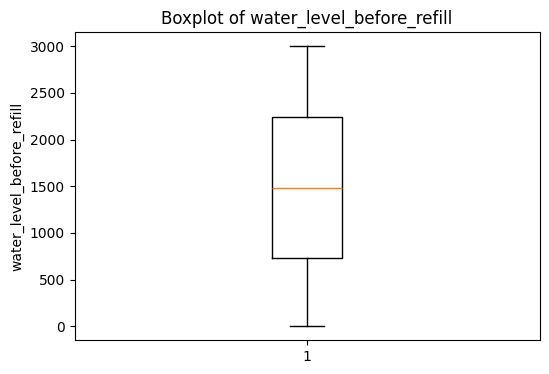

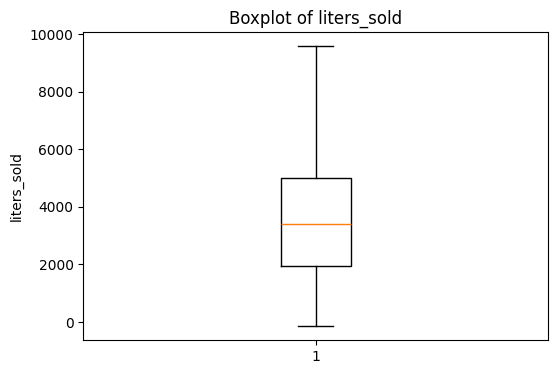

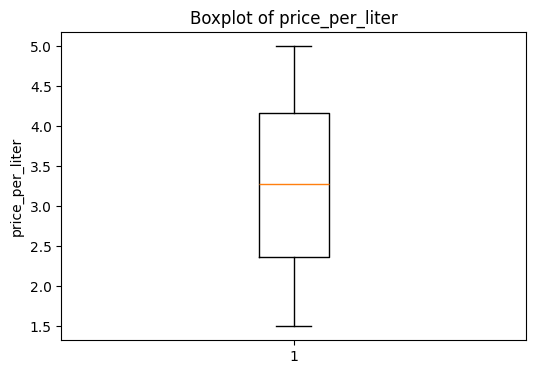

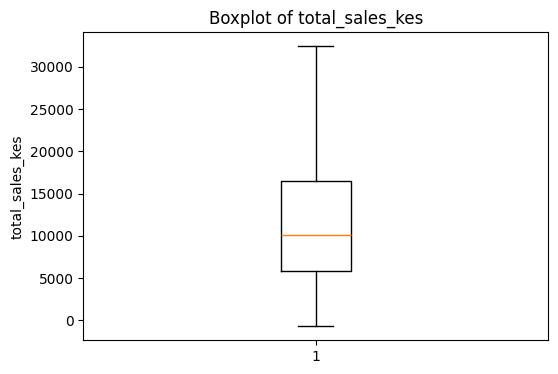

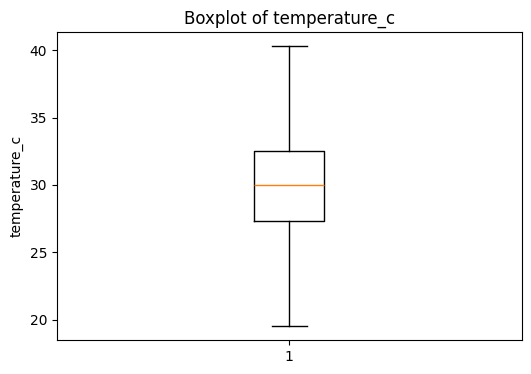

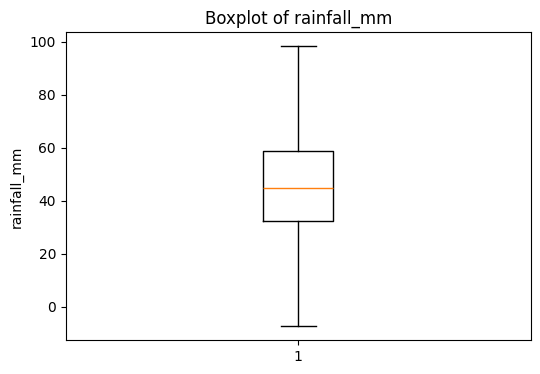

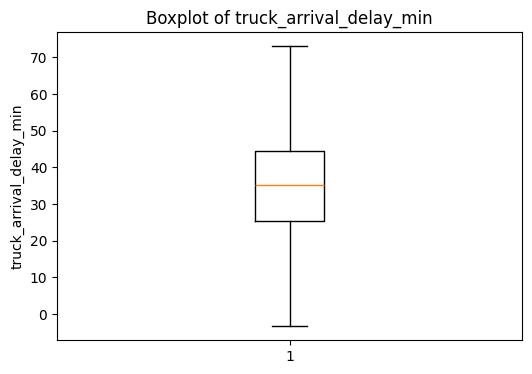

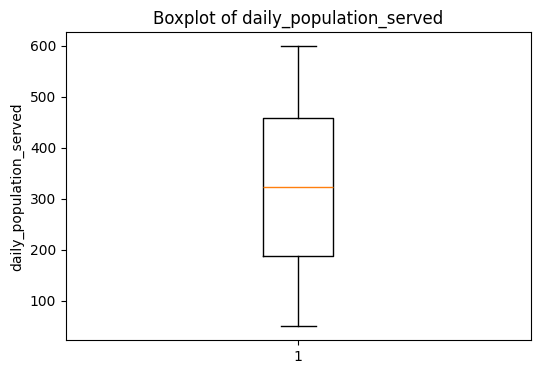

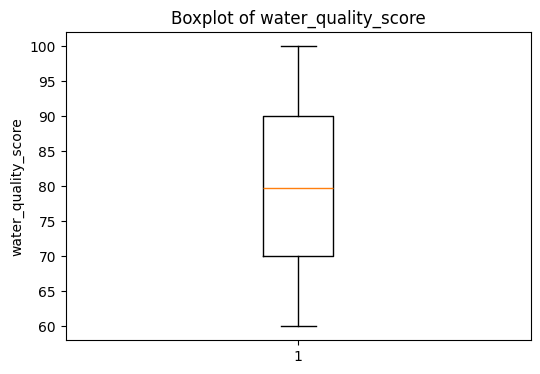

In [133]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

### Generate a correlation matrix

In [134]:
correlation = df[numeric_cols].corr()

correlation

,tank_capacity_liters,water_level_before_refill,liters_sold,price_per_liter,total_sales_kes,temperature_c,rainfall_mm,truck_arrival_delay_min,daily_population_served,water_quality_score
tank_capacity_liters,1.000000,0.009614,0.907111,-0.014925,0.773622,0.012661,0.007211,0.001946,0.008618,0.015090
water_level_before_refill,0.009614,1.000000,0.013876,0.005830,0.018087,-0.000670,0.007282,-0.017223,0.010527,0.012876
liters_sold,0.907111,0.013876,1.000000,-0.005932,0.833961,0.013707,0.001033,-0.001998,0.006382,0.012925
price_per_liter,-0.014925,0.005830,-0.005932,1.000000,0.463170,0.005349,0.021471,-0.018716,-0.000658,-0.003143
total_sales_kes,0.773622,0.018087,0.833961,0.463170,1.000000,0.012663,0.004032,-0.010517,0.003987,0.014873
temperature_c,0.012661,-0.000670,0.013707,0.005349,0.012663,1.000000,0.017596,-0.005096,0.014844,0.005857
rainfall_mm,0.007211,0.007282,0.001033,0.021471,0.004032,0.017596,1.000000,-0.004980,0.036958,0.019868
truck_arrival_delay_min,0.001946,-0.017223,-0.001998,-0.018716,-0.010517,-0.005096,-0.004980,1.000000,0.013247,-0.011208
daily_population_served,0.008618,0.010527,0.006382,-0.000658,0.003987,0.014844,0.036958,0.013247,1.000000,-0.003741
water_quality_score,0.015090,0.012876,0.012925,-0.003143,0.014873,0.005857,0.019868,-0.011208,-0.003741,1.000000


### Plot the correlation Matrix

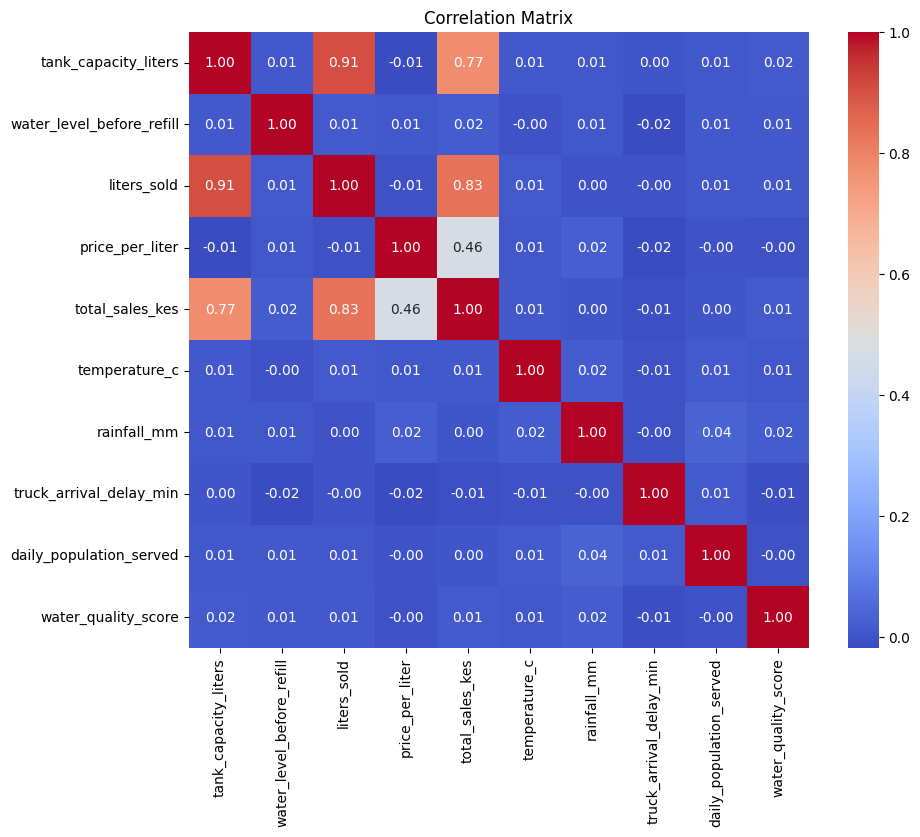

In [135]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.savefig("Correlation_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Trend Analysis (daily water demand)

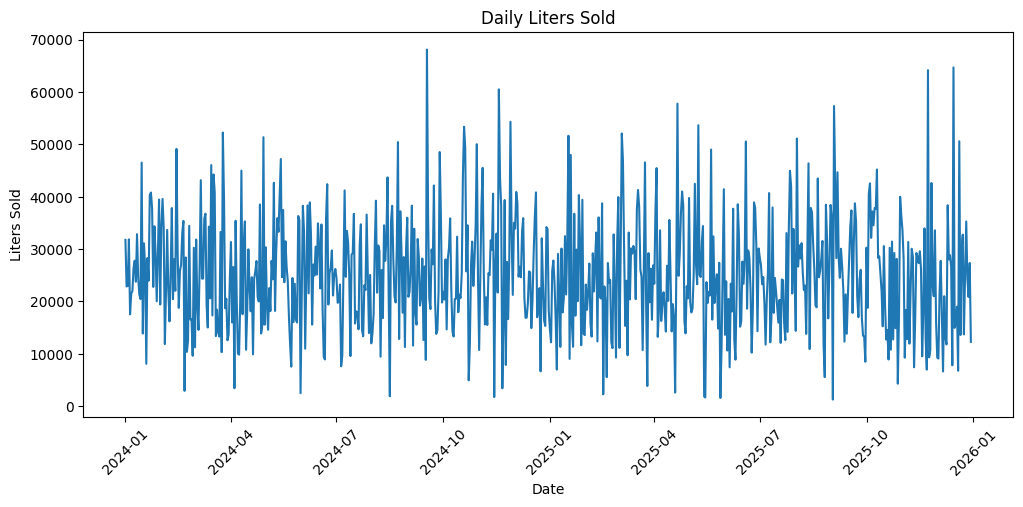

In [136]:
daily_sales = df.groupby("date")["liters_sold"].sum()

plt.figure(figsize=(12,5))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Liters Sold")

plt.xlabel("Date")

plt.ylabel("Liters Sold")

plt.xticks(rotation=45)

plt.show()

# Average liters sold by kiosk location

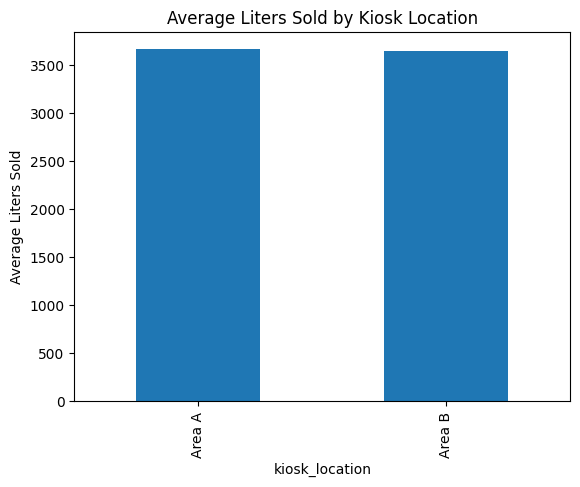

kiosk_location
Area A    3666.186134
Area B    3653.286984
Name: liters_sold, dtype: float64


<Figure size 640x480 with 0 Axes>

In [137]:
location_sales = df.groupby("kiosk_location")["liters_sold"].mean()

location_sales.plot(kind="bar")

plt.title("Average Liters Sold by Kiosk Location")

plt.ylabel("Average Liters Sold")

plt.show()
plt.savefig("Average_Liters_Sold_by_Kiosk_Location.png", dpi=300, bbox_inches="tight")
print (location_sales)


# Average sales by payment

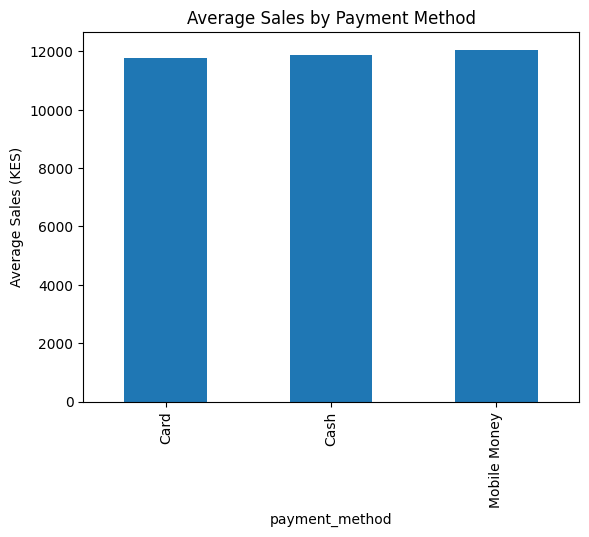

payment_method
Card            11775.481472
Cash            11884.969219
Mobile Money    12062.819408
Name: total_sales_kes, dtype: float64


In [138]:
payment_sales = df.groupby("payment_method")["total_sales_kes"].mean()

payment_sales.plot(kind="bar")

plt.title("Average Sales by Payment Method")

plt.ylabel("Average Sales (KES)")

plt.show()

print (payment_sales)

### Average litres sold by refill status

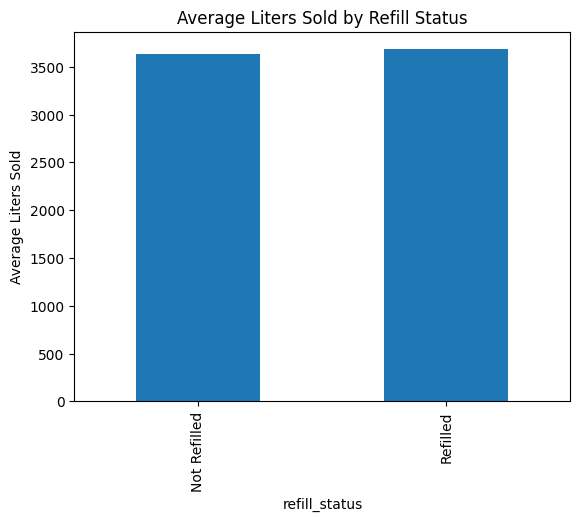

refill_status
Not Refilled    3636.834942
Refilled        3682.391414
Name: liters_sold, dtype: float64


In [139]:
refill = df.groupby("refill_status")["liters_sold"].mean()

refill.plot(kind="bar")

plt.title("Average Liters Sold by Refill Status")

plt.ylabel("Average Liters Sold")

plt.show()

print(refill)

### Average Water quality score by kiosk location

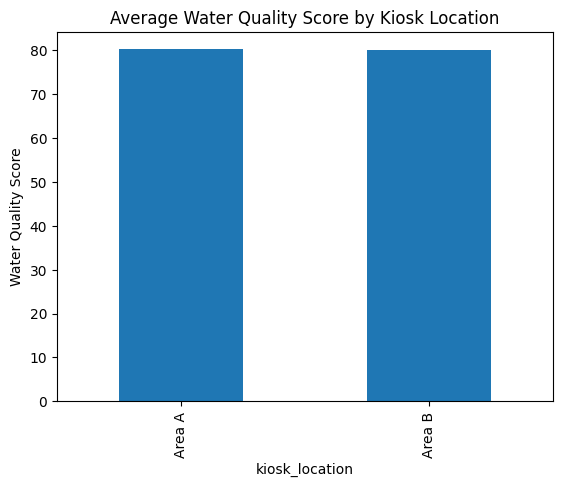

kiosk_location
Area A    80.056486
Area B    79.860383
Name: water_quality_score, dtype: float64


In [140]:
quality = df.groupby("kiosk_location")["water_quality_score"].mean()

quality.plot(kind="bar")

plt.title("Average Water Quality Score by Kiosk Location")

plt.ylabel("Water Quality Score")

plt.show()

print(quality)

### Temperature vs liters sold

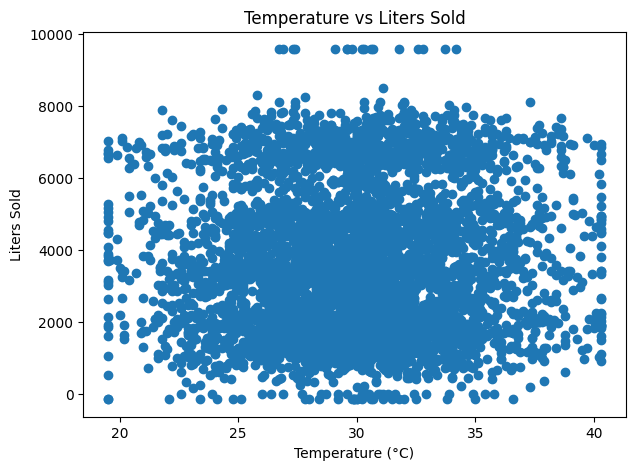

       temperature_c  liters_sold
count     5000.00000  5000.000000
mean        29.94036  3659.850072
std          3.93949  2024.218907
min         19.50000  -150.000000
25%         27.30000  1932.735000
50%         30.00000  3416.435000
75%         32.50000  4990.412500
max         40.30000  9576.928750


In [141]:
plt.figure(figsize=(7,5))

plt.scatter(df["temperature_c"], df["liters_sold"])

plt.xlabel("Temperature (°C)")

plt.ylabel("Liters Sold")

plt.title("Temperature vs Liters Sold")

plt.show()

print(df[["temperature_c", "liters_sold"]].describe())

### Rainfall vs Litres Sold

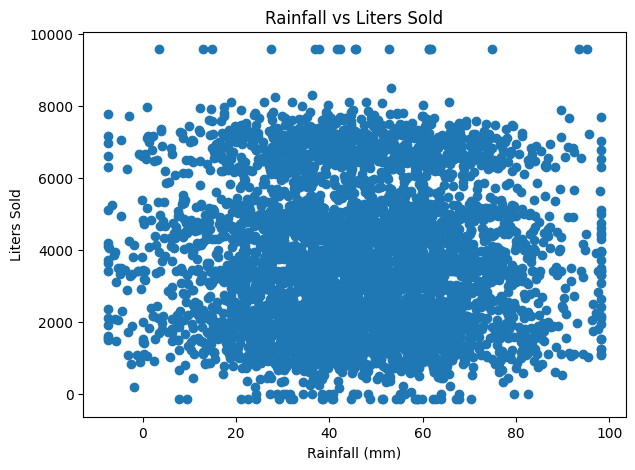

       rainfall_mm  liters_sold
count  5000.000000  5000.000000
mean     45.275200  3659.850072
std      19.789517  2024.218907
min      -7.462500  -150.000000
25%      32.175000  1932.735000
50%      44.650000  3416.435000
75%      58.600000  4990.412500
max      98.237500  9576.928750


In [142]:
plt.figure(figsize=(7,5))

plt.scatter(df["rainfall_mm"], df["liters_sold"])

plt.xlabel("Rainfall (mm)")

plt.ylabel("Liters Sold")

plt.title("Rainfall vs Liters Sold")

plt.show()

print(df[["rainfall_mm", "liters_sold"]].describe())

# Import the required libraries for Modelling

In [143]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Define the features(x) and the Target Variable(y)

In [144]:
X = df_encoded.drop(columns=["liters_sold"])
y = df_encoded["liters_sold"]

### Split the Data into Training and testing Sets

In [145]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### Scale the features

In [146]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train the linear Regression Model

In [147]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Make Predictions

In [148]:
lr_predictions = lr_model.predict(X_test_scaled)

# Evaluate the linear regression Model

In [149]:
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Results
MAE: 396.1713901453787
RMSE: 588.4512321185529
R² Score: 0.9181171903214362


### Train the decision tree model

In [150]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

### Predict Using the Decion Tree

In [151]:
dt_predictions = dt_model.predict(X_test)

# Evaluate Decision Tree Model

In [152]:
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Results")
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Results
MAE: 274.69938
RMSE: 621.5897282834554
R² Score: 0.9086350877037577


### Train the Random Forest Model

In [153]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# Predict Using the Random Forest

In [154]:
rf_predictions = rf_model.predict(X_test)

# Evaluate using the Random Forest

In [155]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE: 169.74939698750003
RMSE: 400.0089916333157
R² Score: 0.962163470821915


### Compare the Models

In [156]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,396.171390,588.451232,0.918117
1,Decision Tree,274.699380,621.589728,0.908635
2,Random Forest,169.749397,400.008992,0.962163


In [157]:
# The best model was random forest

### Test the Model on new/unseen Data

In [158]:
# Create a new DataFrame with 10 unseen observations
new_data = X_test.sample(n=10, random_state=42)

# Display the new dataset
new_data.head(10)

,tank_capacity_liters,water_level_before_refill,price_per_liter,total_sales_kes,temperature_c,rainfall_mm,truck_arrival_delay_min,daily_population_served,water_quality_score,hour,...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
3707,5000.0,1276.21,3.04,11646.42,30.6,46.8,35.2,232,66.2,12,...,False,False,False,False,False,False,False,False,False,False
828,5000.0,1508.95,4.52,16826.92,30.0,37.6,25.8,315,65.2,6,...,True,False,False,False,False,False,False,False,False,False
2664,3000.0,2978.72,3.19,7494.17,33.4,62.6,21.9,540,99.2,20,...,False,False,False,False,False,False,False,False,False,False
1047,5000.0,367.85,2.00,5874.64,22.8,54.5,34.8,232,60.7,13,...,False,False,False,False,False,False,False,False,True,False
3197,2000.0,179.54,3.55,5121.83,36.1,53.8,26.2,504,74.3,9,...,False,False,False,False,False,False,False,False,False,True
4200,2000.0,258.32,2.77,2779.50,29.4,38.9,45.4,107,61.6,7,...,False,False,False,False,False,False,False,True,False,False
1505,10000.0,2562.52,3.61,23135.48,32.2,47.4,7.0,521,87.4,2,...,False,False,False,False,False,False,False,False,True,False
996,2000.0,318.05,4.80,9586.90,27.7,60.6,65.8,444,66.1,16,...,False,False,False,False,True,False,False,False,False,False
2750,5000.0,2545.83,3.68,15082.00,26.2,36.8,11.6,315,79.8,21,...,False,False,True,False,False,False,False,False,False,False
4445,3000.0,1088.31,4.76,14261.58,31.8,56.2,40.4,497,79.8,10,...,False,False,False,False,False,False,True,False,False,False


In [159]:
print("Shape of new data:", new_data.shape)

Shape of new data: (10, 34)


### Make predictions

In [160]:
predictions = rf_model.predict(new_data)

print(predictions)

[3687.8758  3688.43015 2409.61485 2978.4458  1557.74395 1001.207
 6321.21785 2010.5955  4032.0401  2934.1892 ]


### Compare the predictions with the actual values

In [161]:
actual_values = y_test.loc[new_data.index]

comparison = pd.DataFrame({
    "Actual_Liters_Sold": actual_values,
    "Predicted_Liters_Sold": predictions
})

comparison

,Actual_Liters_Sold,Predicted_Liters_Sold
3707,3831.06,3687.87580
828,3722.77,3688.43015
2664,2349.27,2409.61485
1047,2937.32,2978.44580
3197,1442.77,1557.74395
4200,1003.43,1001.20700
1505,6408.72,6321.21785
996,1997.27,2010.59550
2750,4098.37,4032.04010
4445,2996.13,2934.18920


### Calculate the prediction error

In [162]:
comparison["Error"] = comparison["Predicted_Liters_Sold"] - comparison["Actual_Liters_Sold"]

comparison

,Actual_Liters_Sold,Predicted_Liters_Sold,Error
3707,3831.06,3687.87580,-143.18420
828,3722.77,3688.43015,-34.33985
2664,2349.27,2409.61485,60.34485
1047,2937.32,2978.44580,41.12580
3197,1442.77,1557.74395,114.97395
4200,1003.43,1001.20700,-2.22300
1505,6408.72,6321.21785,-87.50215
996,1997.27,2010.59550,13.32550
2750,4098.37,4032.04010,-66.32990
4445,2996.13,2934.18920,-61.94080


### Feature importance

### Generate the feature importance table

In [163]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,tank_capacity_liters,0.808198
3,total_sales_kes,0.135548
2,price_per_liter,0.033519
5,rainfall_mm,0.003534
1,water_level_before_refill,0.002839
8,water_quality_score,0.002692
6,truck_arrival_delay_min,0.002445
7,daily_population_served,0.002277
4,temperature_c,0.002233
9,hour,0.001421


### Plot the feature importance

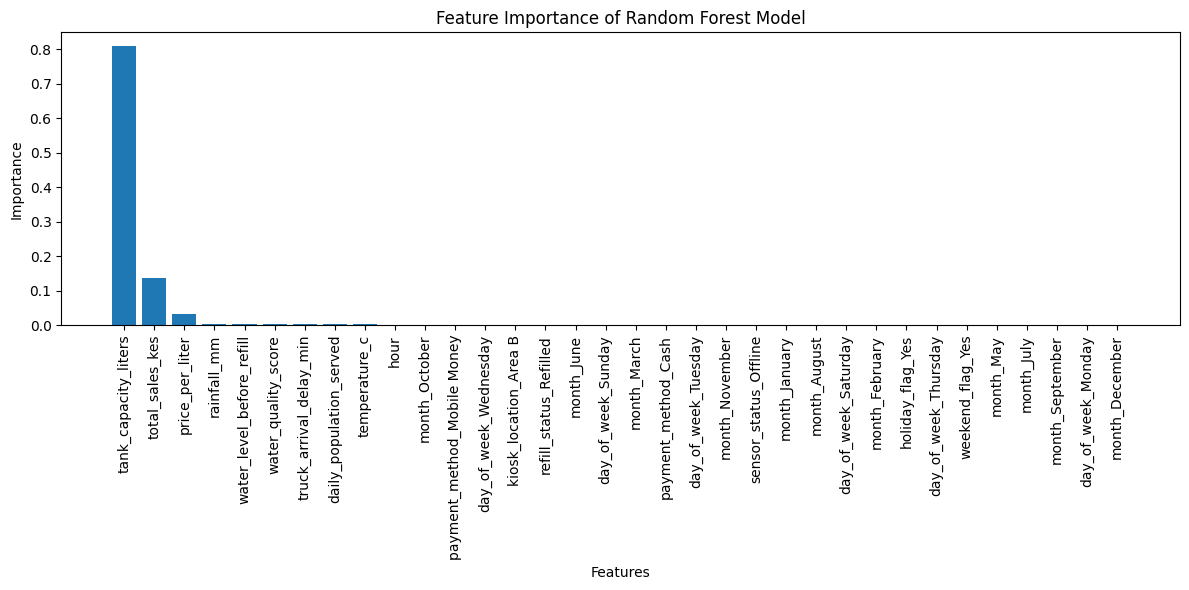

In [164]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(feature_importance['Feature'],
        feature_importance['Importance'])

plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance of Random Forest Model")

plt.tight_layout()
plt.show()

In [165]:
#Feature importance analysis was conducted to determine which predictor variables contributed most to the Random Forest model.
#Features with higher importance scores had a greater influence on predicting water demand, while features with lower scores had less impact.

### Cross validation

In [166]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-validation scores:")
print(cv_scores)

print("\nAverage R² Score:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[0.96777073 0.95655354 0.96295032 0.96411573 0.948657  ]

Average R² Score:
0.960009463949968

Standard Deviation:
0.006731556926786333


### Hyperparameter Tuning

In [167]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

### View the best parameters

In [168]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-validation Score:
0.9611833387142455


### Build the optimized model

In [169]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Evaluate the optimized model

In [170]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

predictions = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 163.12342650532224
RMSE: 390.59256102005696
R² Score: 0.963923888644763


### Compare the original and the optimized model

In [171]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Original Random Forest metrics
original_mae = mean_absolute_error(y_test, rf_predictions)
original_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
original_r2 = r2_score(y_test, rf_predictions)

# Optimized Random Forest metrics
optimized_mae = mean_absolute_error(y_test, predictions)
optimized_rmse = np.sqrt(mean_squared_error(y_test, predictions))
optimized_r2 = r2_score(y_test, predictions)

# Comparison table
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Original Random Forest': [original_mae, original_rmse, original_r2],
    'Optimized Random Forest': [optimized_mae, optimized_rmse, optimized_r2]
})

comparison

,Metric,Original Random Forest,Optimized Random Forest
0,MAE,169.749397,163.123427
1,RMSE,400.008992,390.592561
2,R² Score,0.962163,0.963924
